In [ ]:
import math
import itertools
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import os
from matplotlib.colors import ListedColormap

def fermi(focal, neighbor, K=0.3):
    return 1 / (1 + pow(math.e, (focal - neighbor) / K))

def calculate_fitness(G, T, a, b, o, population, rep_mat, accuracy):
    size_x, size_y = population.shape
    fitnesses = np.zeros((size_x, size_y))
    new_accuracy = accuracy.copy()


    for i in range(size_x):
        for j in range(size_y):
            strategy = population[i, j]
            total_payoff = 0
            neighbors = []
            if i > 0:
                neighbors.append((i - 1, j))
            if i < size_x - 1:
                neighbors.append((i + 1, j))
            if j > 0:
                neighbors.append((i, j - 1))
            if j < size_y - 1:
                neighbors.append((i, j + 1))

            for x, y in neighbors:
                neighbor_strategy = population[x, y]
                focal, neighbor = i * size_x + j, x * size_x + y
                delta = 0
                if neighbor_strategy == 'C':
                    noise = np.random.normal(0, 0.2)
                    acc = np.mean([accuracy[focal], accuracy[neighbor]]) + noise
                    # improvement = (1 - acc/100) * np.random.uniform(0.1, 0.5
                    improvement =  (1 - acc/100) * (1 - np.exp(-0.5 * 2))
                    acc = np.clip(acc + improvement, 0, 100)
                    delta += (acc - accuracy[focal])

                payoff_matrix = {
                    'C': {'C': a * abs(delta) - T - o, 'D': - o},
                    'D': {'C': b * delta - T - o, 'D': 0}
                }

                if rep_mat is not None:
                    CC = a * abs(delta) - T - o
                    if CC >= 0: CC = CC * rep_mat[i, j].item()
                    else: CC = CC / rep_mat[i, j].item()

                    DC = b * delta - T - o
                    if DC >= 0: DC = DC * rep_mat[i, j].item()
                    else: DC = DC / rep_mat[i, j].item()
                    payoff_matrix = {
                        'C': {'C': CC, 'D': - o/rep_mat[i, j].item()},
                        'D': {'C': DC, 'D': 0}
                    }
                total_payoff += payoff_matrix[strategy][neighbor_strategy]

            focal = i * size_x + j
            list_acc = [accuracy[focal]]
            for x, y in neighbors:
                if population[x, y] == 'C':
                    list_acc.append(accuracy[x * size_x + y])

            noise = np.random.normal(0, 0.2)
            acc = np.mean(list_acc) + noise
            # improvement = (1 - acc/100) * np.random.uniform(0.1, 0.5)
            improvement =  (1 - acc/100) * (1 - np.exp(-0.5 * len(list_acc)))
            acc = np.clip(acc + improvement, 0, 100)
            new_accuracy[focal] = acc
            fitnesses[i, j] = total_payoff

    return fitnesses, new_accuracy

def visualize_population(population):
    numeric = np.where(population == 'C', 0, 1)

    cmap = ListedColormap(['green', 'red'])

    plt.imshow(numeric, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    plt.axis('off')
    plt.show()
    save_figure(plt, filename=f"population_{int(time.time())}.png")

def visualize_accuracy(accuracy):
    plt.imshow(accuracy, cmap='magma', vmin=0, vmax=100)
    plt.colorbar(label='Accuracy')
    plt.axis('off')
    plt.show()
    save_figure(plt, filename=f"accuracy_{int(time.time())}.png")


def save_figure(plt, filename="figure.png"):
    dirpath = os.path.dirname(filename)
    if dirpath:
        os.makedirs(dirpath, exist_ok=True)
    plt.savefig(filename)
    plt.close()

In [ ]:
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

FERMI_K = 0.3

def get_fittest_neighbor(neighbors, fitnesses):
    best_pos = neighbors[0]
    for pos in neighbors[1:]:
        if fitnesses[pos] > fitnesses[best_pos]:
            best_pos = pos
    return best_pos

def update_population(population, fitnesses, deterministic, K=FERMI_K):
    new_population = population.copy()

    (size_x, size_y) = population.shape

    for i in range(size_x):
        for j in range(size_y):
            neighbors = []
            if i > 0:
                neighbors.append((i - 1, j))
            if i < size_x - 1:
                neighbors.append((i + 1, j))
            if j > 0:
                neighbors.append((i, j - 1))
            if j < size_y - 1:
                neighbors.append((i, j + 1))

            if not neighbors:
                continue

            if deterministic:
                neighbor_pos = get_fittest_neighbor(neighbors, fitnesses)
                if fitnesses[neighbor_pos] > fitnesses[i, j]:
                    new_population[i, j] = population[neighbor_pos]
            else:
                focal_fitness = fitnesses[i, j]
                neighbor_pos = random.choice(neighbors)
                neighbor_strategy = population[neighbor_pos]
                neighbor_fitness = fitnesses[neighbor_pos]

                prob = fermi(focal_fitness, neighbor_fitness, K)

                if random.random() < prob:
                    new_population[i, j] = neighbor_strategy

    return new_population

def simulate_population(size_x=100, size_y=100, generations=50, initial_cooperator_ratio=0.5,
                        G=1, T=1, a=2, b=0.5, r=0.1, o=2, epochs=2, reputation=False,
                        deterministic=False, save_figures=False, show_final_population=False,
                        save_data=False, figure_path='fig', data_path='data'):

    rep_mat = np.ones((size_x, size_y)) if reputation else None
    accuracy = np.random.uniform(20, 40, size_x * size_y)

    population = np.random.choice(['C', 'D'], size=(size_x, size_y), p=[initial_cooperator_ratio, 1 - initial_cooperator_ratio])
    history_frequency = []
    history_fitnesses = []
    history_accuracy = []

    print('Initilization')
    visualize_population(population)
    visualize_accuracy(np.array(accuracy).reshape(size_x, size_y))

    for gen in range(generations):
        cooperator_count = sum((sum(row == 'C') for row in population))
        # if cooperator_count == 0 or cooperator_count == size_x * size_y:
            # if gen % 10 == 0:
                # history_frequency.append(cooperator_count)
            # break
            # continue

        history_frequency.append(cooperator_count)
        fitnesses, accuracy = calculate_fitness(G, T, a, b, o, population, rep_mat, accuracy)

        total_fitness = np.sum(fitnesses)
        history_fitnesses.append(total_fitness)
        avg_acc = sum(accuracy) / len(accuracy)
        # avg_acc = np.var(accuracy)
        history_accuracy.append(avg_acc)

        if rep_mat is not None:
            for i in range(size_x):
                for j in range(size_y):
                    rep_mat[i, j] = min(1.5, rep_mat[i, j] + r) if population[i, j] == 'C' else max(0.5, rep_mat[i, j] - r)

        population = update_population(population, fitnesses, deterministic, K=FERMI_K)
        # if show_final_population:
        #     print('Generation', gen)
        #     visualize_population(population)

    print('Final results')
    if save_figures:
        path = figure_path

        # Show history frequency
        plt.ylim(0, 100)
        plt.xlim(0, generations)
        plt.plot(np.array(history_frequency) / (size_x * size_y) * 100, label='Cooperator Frequency')
        plt.xlabel('Generation')
        plt.ylabel('Number of Cooperators')
        plt.title('Cooperator Count Over Generations')
        plt.show()
        save_figure(plt, filename=f'{path}_cooperator-history.png')

        # Show history fitness
        plt.xlim(0, generations)
        plt.plot(np.array(history_fitnesses), label='Total fitness')
        plt.xlabel('Generation')
        plt.ylabel('Total fitness')
        plt.title('Total fitness Over Generations')
        plt.show()
        save_figure(plt, filename=f'{path}_fitness-history.png')

        # Show history accuracy
        plt.xlim(0, generations)
        plt.plot(np.array(history_accuracy), label='Total fitness')
        plt.xlabel('Generation')
        plt.ylabel('Average accuracy')
        plt.title('Average accuracy Over Generations')
        plt.show()
        save_figure(plt, filename=f'{path}_accuracy-history.png')

    if show_final_population:
        visualize_population(population)
        visualize_accuracy(np.array(accuracy).reshape(size_x, size_y))

    if save_data:
        # print(history_frequency)
        # print(history_fitnesses)
        # print(history_accuracy)
        save_data_path = data_path
        data = pd.DataFrame({
            'Cooperator Count': history_frequency,
            'Total fitness': history_fitnesses,
        })
        # Ensure directory exists before writing CSV
        import os as _os
        _os.makedirs(_os.path.dirname(f'{save_data_path}/data.csv'), exist_ok=True)
        data.to_csv(f'{save_data_path}_data.csv', index_label='Generation')

    return population, history_frequency, history_fitnesses, history_accuracy

Seeds:   0%|          | 0/1 [00:00<?, ?it/s]

Initilization


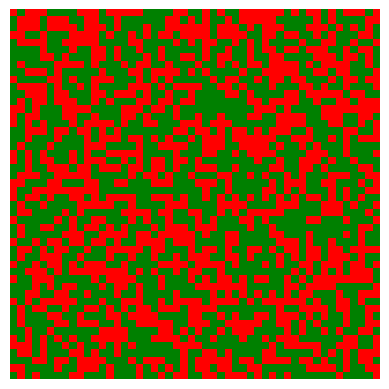

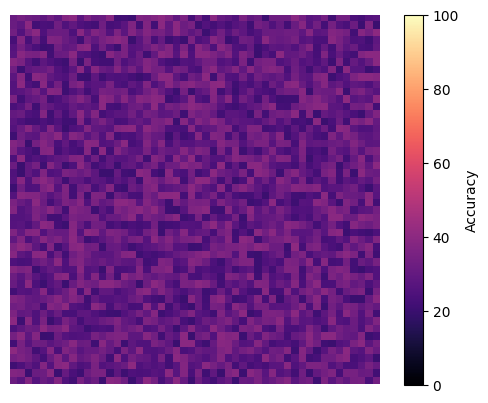

Final results


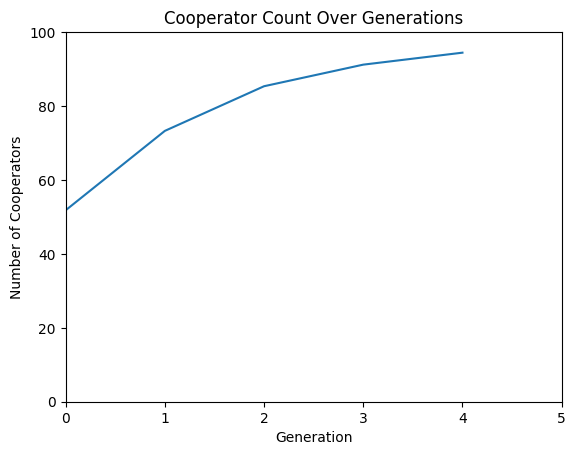

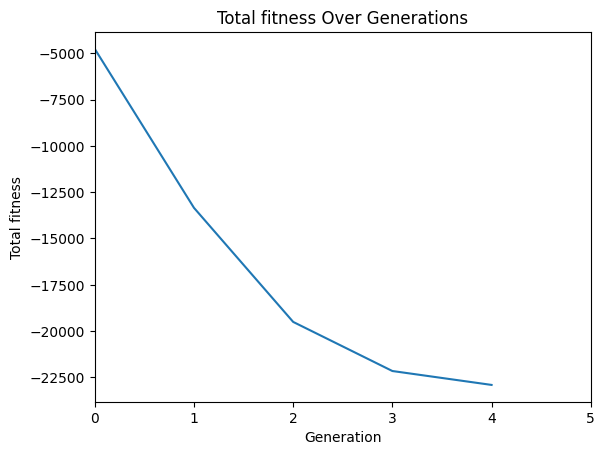

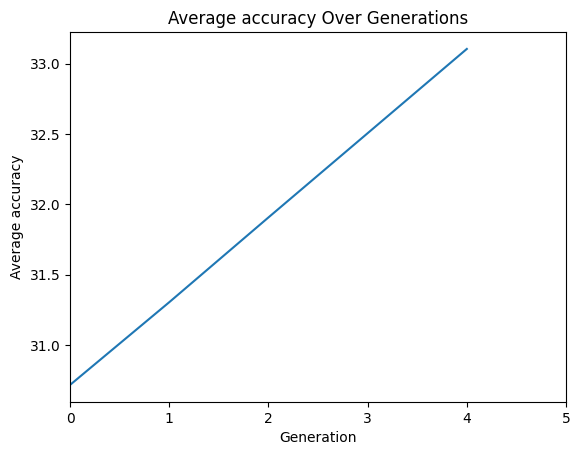

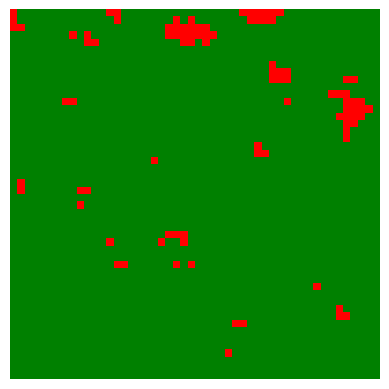

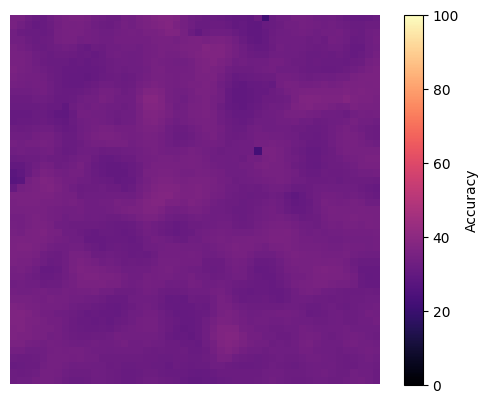

Seeds: 100%|██████████| 1/1 [00:05<00:00,  5.12s/it]


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import itertools
import argparse
try:
    from tqdm import tqdm
except Exception:
    def tqdm(iterable, *args, **kwargs):
        return iterable

def __main__():
    parser = argparse.ArgumentParser(description='Simulate population dynamics.')
    parser.add_argument('--size_x', type=int, default=50, help='network size x')
    parser.add_argument('--size_y', type=int, default=50, help='network size y')
    parser.add_argument('--gen', type=int, default=5, help='generations')
    parser.add_argument('--epochs', type=int, default=2, help='local epochs')
    parser.add_argument('--G', type=float, default=1, help='cost')
    parser.add_argument('--T', type=float, default=3, help='cost')
    parser.add_argument('--a', type=float, default=1.5, help='CD >= 1')
    parser.add_argument('--b', type=float, default=0.5, help='DC < 1')
    parser.add_argument('--rep', type=bool, default=True, help='reputation')
    parser.add_argument('--r', type=float, default=0.05, help='r')
    parser.add_argument('--o', type=float, default=0.5, help='send')
    parser.add_argument('--det', type=bool, default=False, help='deterministic')
    parser.add_argument('--seed-start', type=int, default=0, help='Starting seed for simulations')
    parser.add_argument('--seed-end', type=int, default=1, help='Ending seed for simulations')

    args = parser.parse_known_args()[0]
    seed_start = args.seed_start
    seed_end = args.seed_end

    # Generate theta run for POP
    # Run with different seed
    seeds = range(seed_start, seed_end)
    for seed in tqdm(seeds, desc='Seeds'):
        np.random.seed(seed)

        res_freq = []
        res_fitness = []
        res_acc= []

        final_population, history_frequency, history_fitness, history_accuracy = simulate_population(
            size_x=args.size_x, size_y=args.size_y, generations=args.gen, initial_cooperator_ratio=0.5,
            G=args.G, T=args.T, a=args.a, b=args.b, r=args.r, o=args.o, epochs=args.epochs, reputation=args.rep,
            deterministic=args.det, save_figures=True, show_final_population=True, save_data=True,
        )

        res_freq.append((seed, [int(x) for x in history_frequency]))
        res_fitness.append((seed, [float(x) for x in history_fitness[1:]]))
        res_acc.append((seed, [float(x) for x in history_accuracy]))

        # Use strategy and game-type specific directory
        data_dir = 'data'

        os.makedirs(data_dir, exist_ok=True)

        file_prefix = f'{data_dir}/seed_{seed}'

        df = pd.DataFrame(res_freq, columns=['Seed', 'Cooperator_Frequency'])
        df.to_csv(f'{file_prefix}_cooperator_frequency.csv', index=False)

        df = pd.DataFrame(res_fitness, columns=['Seed', 'Payoff'])
        df.to_csv(f'{file_prefix}_population_payoff.csv', index=False)

        df = pd.DataFrame(res_acc, columns=['Seed', 'Accuracy'])
        df.to_csv(f'{file_prefix}_population_accuracy.csv', index=False)

        # # D. THÊM MỚI: Đồ thị Phương sai Độ chính xác (Tô bóng mờ màu xanh ngọc - Teal)
        # # plt.figure(figsize=(6, 4))
        # # plt.plot(0, history_accuracy, color='#16a085', linewidth=2)
        # plt.fill_between(range(5), history_accuracy, color='#8e44ad', alpha=1.0)
        # plt.ylim(0, 15)
        # plt.yticks(np.arange(0, 15, 3))
        # plt.xticks(np.arange(0, 151, 30))
        # plt.xlabel('generation', fontsize=13)
        # plt.ylabel('variance', fontsize=13)
        # plt.yticks(np.arange(0, 16, 3))
        # plt.title('Accuracy variance', fontsize=15, fontweight='bold', pad=20)
        # plt.grid(True, linestyle=':', alpha=0.35)
        # plt.tight_layout()
        # plt.show()
        # # save_figure(plt, filename=f'{path}_variance-history.png')

__main__()